# ðŸŽ¯ Advanced A/B Test Analysis: E-Commerce Pricing Strategy

## Comprehensive Statistical Hypothesis Testing

**Project:** E-Commerce Pricing Strategy Optimization  
**Date:** October 4, 2026  
**Analyst:** Data Science Team

---

## ðŸ“Š Executive Summary

This notebook provides a **comprehensive, production-grade A/B test analysis** far exceeding standard reports.

**Dataset:** 294,478 sessions â†’ 290,584 cleaned records

### Statistical Methods Applied:
- âœ… Z-Test for Proportions
- âœ… Chi-Square Test of Independence
- âœ… Two-Sample T-Test
- âœ… Logistic Regression with Country Effects
- âœ… Bayesian A/B Testing
- âœ… Statistical Power Analysis
- âœ… Effect Size Calculations
- âœ… Segmentation Analysis

---

## ðŸ“‘ Table of Contents

1. [Setup & Data Loading](#setup)
2. [Exploratory Data Analysis](#eda)
3. [Data Cleaning](#cleaning)
4. [Descriptive Statistics](#descriptive)
5. [Hypothesis Testing](#hypothesis)
6. [Segmentation Analysis](#segmentation)
7. [Bayesian Analysis](#bayesian)
8. [Business Impact](#business)
9. [Conclusions](#conclusions)

---
<a id='setup'></a>
## 1. ðŸ“¦ Setup & Data Loading

In [1]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# IMPORT LIBRARIES
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Statistical Analysis
from scipy import stats
from scipy.stats import chi2_contingency, norm, beta
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.formula.api import logit
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook', font_scale=1.1)
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

# Random seed
np.random.seed(42)

print('â•'*70)
print(' '*25 + 'âœ“ SETUP COMPLETE')
print('â•'*70)
print(f'Analysis Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Pandas v{pd.__version__} | NumPy v{np.__version__}')
print('â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                         âœ“ SETUP COMPLETE
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
Analysis Date: 2026-10-04 13:40:00
Pandas v3.0.5 | NumPy v2.5.3
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•


In [2]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# LOAD DATASETS
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('\n' + 'â•'*70)
print(' '*25 + 'ðŸ“‚ LOADING DATA')
print('â•'*70)

df_ab = pd.read_csv('ab_data.csv')
df_countries = pd.read_csv('countries.csv')

print(f'\nâœ“ AB Test Data: {df_ab.shape[0]:,} rows Ã— {df_ab.shape[1]} columns')
print(f'âœ“ Countries Data: {df_countries.shape[0]:,} rows Ã— {df_countries.shape[1]} columns')

print('\n' + 'â”€'*70)
print('AB Test Data - Preview:')
print('â”€'*70)
display(df_ab.head())

print('\n' + 'â”€'*70)
print('Countries Data - Preview:')
print('â”€'*70)
display(df_countries.head())


â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                         ðŸ“‚ LOADING DATA
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

âœ“ AB Test Data: 294,478 rows Ã— 5 columns
âœ“ Countries Data: 290,584 rows Ã— 2 columns

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
AB Test Data - Preview:
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1



â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Countries Data - Preview:
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


---
<a id='eda'></a>
## 2. ðŸ” Exploratory Data Analysis

In [3]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# DATASET OVERVIEW
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*23 + 'ðŸ“Š DATASET OVERVIEW')
print('â•'*70)

# Basic metrics
total_sessions = len(df_ab)
unique_users = df_ab['user_id'].nunique()
duplicate_sessions = total_sessions - unique_users

print(f'\nðŸ“ˆ Size Metrics:')
print(f'  Total sessions: {total_sessions:,}')
print(f'  Unique users: {unique_users:,}')
print(f'  Duplicates: {duplicate_sessions:,} ({duplicate_sessions/total_sessions*100:.2f}%)')

# Time period
df_ab['timestamp'] = pd.to_datetime(df_ab['timestamp'])
start_date = df_ab['timestamp'].min()
end_date = df_ab['timestamp'].max()
duration = (end_date - start_date).days

print(f'\nðŸ“… Test Period:')
print(f'  Start: {start_date}')
print(f'  End: {end_date}')
print(f'  Duration: {duration} days')

# Group distribution
print(f'\nðŸ‘¥ Group Distribution:')
group_counts = df_ab['group'].value_counts()
for group, count in group_counts.items():
    print(f'  {group}: {count:,} ({count/total_sessions*100:.2f}%)')

balance = group_counts.min() / group_counts.max()
print(f'\n  Balance Ratio: {balance:.4f}')
print(f'  Status: {"âœ“ Well-balanced" if balance > 0.95 else "âš ï¸ Imbalanced"}')

# Conversions
print(f'\nðŸ’° Conversion Overview:')
conversions = df_ab['converted'].sum()
overall_cr = df_ab['converted'].mean()
print(f'  Total conversions: {conversions:,}')
print(f'  Overall CR: {overall_cr*100:.2f}%')

# Countries
print(f'\nðŸŒ Country Distribution:')
country_counts = df_countries['country'].value_counts()
for country, count in country_counts.items():
    print(f'  {country}: {count:,} ({count/len(df_countries)*100:.2f}%)')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                       ðŸ“Š DATASET OVERVIEW
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“ˆ Size Metrics:
  Total sessions: 294,478
  Unique users: 290,584
  Duplicates: 3,894 (1.32%)

ðŸ“… Test Period:
  Start: 2017-01-02 13:42:05.378582
  End: 2017-01-24 13:41:54.460509
  Duration: 21 days

ðŸ‘¥ Group Distribution:
  treatment: 147,276 (50.01%)
  control: 147,202 (49.99%)

  Balance Ratio: 0.9995
  Status: âœ“ Well-balanced

ðŸ’° Conversion Overview:
  Total conversions: 35,237
  Overall CR: 11.97%

ðŸŒ Country Distribution:
  US: 203,619 (70.07%)
  UK: 72,466 (24.94%)
  CA: 14,499 (4.99%)

â•â•â•â•â•â•

In [4]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# DATA QUALITY ASSESSMENT
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('\n' + 'â•'*70)
print(' '*20 + 'ðŸ”¬ DATA QUALITY CHECK')
print('â•'*70)

# 1. Missing values
print('\n1ï¸âƒ£  Missing Values:')
missing_ab = df_ab.isnull().sum()
print('  AB Data:', 'None âœ“' if not missing_ab.any() else missing_ab[missing_ab > 0])
missing_countries = df_countries.isnull().sum()
print('  Countries:', 'None âœ“' if not missing_countries.any() else missing_countries[missing_countries > 0])

# 2. Duplicates
dup_count = df_ab['user_id'].duplicated().sum()
print(f'\n2ï¸âƒ£  Duplicate Users:')
print(f'  Found: {dup_count:,} ({dup_count/len(df_ab)*100:.2f}%)')

# 3. Group-Page alignment
print(f'\n3ï¸âƒ£  Group-Page Alignment:')
crosstab = pd.crosstab(df_ab['group'], df_ab['landing_page'])
print(crosstab)

mismatch_control = ((df_ab['group'] == 'control') & (df_ab['landing_page'] == 'new_page')).sum()
mismatch_treatment = ((df_ab['group'] == 'treatment') & (df_ab['landing_page'] == 'old_page')).sum()
total_mismatches = mismatch_control + mismatch_treatment

print(f'\n  Mismatches: {total_mismatches:,} ({total_mismatches/len(df_ab)*100:.2f}%)')
if total_mismatches > 0:
    print(f'    Control â†’ new_page: {mismatch_control:,}')
    print(f'    Treatment â†’ old_page: {mismatch_treatment:,}')

print('\n' + 'â•'*70)


â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                    ðŸ”¬ DATA QUALITY CHECK
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

1ï¸âƒ£  Missing Values:
  AB Data: None âœ“
  Countries: None âœ“

2ï¸âƒ£  Duplicate Users:
  Found: 3,894 (1.32%)

3ï¸âƒ£  Group-Page Alignment:
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

  Mismatches: 3,893 (1.32%)
    Control â†’ new_page: 1,928
    Treatment â†’ old_page: 1,965

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

---
<a id='cleaning'></a>
## 3. ðŸ§¹ Data Cleaning

### Cleaning Steps:
1. Remove group-page mismatches
2. Remove duplicate users (keep first)
3. Merge with country data
4. Create derived features

In [5]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# DATA CLEANING PIPELINE
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*23 + 'ðŸ§¹ DATA CLEANING')
print('â•'*70)

original_size = len(df_ab)
print(f'\nðŸ“Š Original: {original_size:,} rows\n')

# STEP 1: Remove mismatches
print('â”€'*70)
print('STEP 1: Removing Group-Page Mismatches')
print('â”€'*70)

valid = (
    ((df_ab['group'] == 'control') & (df_ab['landing_page'] == 'old_page')) |
    ((df_ab['group'] == 'treatment') & (df_ab['landing_page'] == 'new_page'))
)

df_clean = df_ab[valid].copy()
removed = original_size - len(df_clean)
print(f'âœ“ Removed: {removed:,} rows')
print(f'  Remaining: {len(df_clean):,}\n')

# STEP 2: Remove duplicates
print('â”€'*70)
print('STEP 2: Removing Duplicate Users')
print('â”€'*70)

before = len(df_clean)
df_clean = df_clean.sort_values('timestamp').drop_duplicates('user_id', keep='first')
removed_dups = before - len(df_clean)
print(f'âœ“ Removed: {removed_dups:,} duplicates')
print(f'  Remaining: {len(df_clean):,}\n')

# STEP 3: Merge countries
print('â”€'*70)
print('STEP 3: Merging Country Data')
print('â”€'*70)

before_merge = len(df_clean)
df_final = df_clean.merge(df_countries, on='user_id', how='inner')
print(f'âœ“ Merged successfully')
print(f'  Final: {len(df_final):,} rows\n')

# STEP 4: Add features
print('â”€'*70)
print('STEP 4: Creating Features')
print('â”€'*70)

df_final['timestamp'] = pd.to_datetime(df_final['timestamp'])
df_final['date'] = df_final['timestamp'].dt.date
df_final['hour'] = df_final['timestamp'].dt.hour
df_final['day_of_week'] = df_final['timestamp'].dt.day_name()
df_final['week'] = df_final['timestamp'].dt.isocalendar().week
df_final['is_weekend'] = df_final['timestamp'].dt.dayofweek >= 5

print('âœ“ Added: date, hour, day_of_week, week, is_weekend\n')

# Summary
print('â•'*70)
print(' '*21 + 'ðŸ“Š CLEANING SUMMARY')
print('â•'*70)
print(f'\nOriginal:    {original_size:,} rows')
print(f'Final:       {len(df_final):,} rows')
print(f'Removed:     {original_size - len(df_final):,} rows')
print(f'Retention:   {len(df_final)/original_size*100:.2f}%')
print(f'\nColumns:     {df_final.shape[1]}')
print(f'Unique users: {df_final["user_id"].nunique():,}')

print('\n' + 'â•'*70)
print(' '*21 + 'âœ“ CLEANED DATA PREVIEW')
print('â•'*70 + '\n')
display(df_final.head(10))

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                       ðŸ§¹ DATA CLEANING
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Original: 294,478 rows

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
STEP 1: Removing Group-Page Mismatches
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
âœ“ Removed: 3,893 rows
  Remaining: 290,585


,user_id,timestamp,group,landing_page,converted,country,date,hour,day_of_week,week,is_weekend
0,922696,2017-01-02 13:42:05.378582,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
1,781507,2017-01-02 13:42:15.234051,control,old_page,0,UK,2017-01-02,13,Monday,1,False
2,737319,2017-01-02 13:42:21.786186,control,old_page,0,US,2017-01-02,13,Monday,1,False
3,818377,2017-01-02 13:42:26.640581,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
4,725857,2017-01-02 13:42:27.851110,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
5,762651,2017-01-02 13:42:28.522322,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
6,722516,2017-01-02 13:42:34.033708,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
7,688937,2017-01-02 13:42:41.406986,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
8,781125,2017-01-02 13:42:45.090432,treatment,new_page,0,US,2017-01-02,13,Monday,1,False
9,799109,2017-01-02 13:42:45.219901,control,old_page,0,US,2017-01-02,13,Monday,1,False


---
<a id='descriptive'></a>
## 4. ðŸ“ˆ Descriptive Statistics & Visualizations

In [6]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# GROUP-LEVEL CONVERSION RATES
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*15 + 'ðŸ“Š CONVERSION RATE BY GROUP')
print('â•'*70)

# Calculate metrics
group_stats = df_final.groupby('group').agg({
    'user_id': 'count',
    'converted': ['sum', 'mean']
}).round(4)

group_stats.columns = ['n_users', 'conversions', 'conv_rate']
group_stats['conv_rate_pct'] = group_stats['conv_rate'] * 100

print('\n')
display(group_stats)

# Calculate difference
control_cr = group_stats.loc['control', 'conv_rate']
treatment_cr = group_stats.loc['treatment', 'conv_rate']
absolute_diff = treatment_cr - control_cr
relative_diff = (absolute_diff / control_cr) * 100

print(f'\nðŸ“Š Key Metrics:')
print(f'  Control CR:     {control_cr*100:.2f}%')
print(f'  Treatment CR:   {treatment_cr*100:.2f}%')
print(f'  Absolute Diff:  {absolute_diff*100:.3f} percentage points')
print(f'  Relative Diff:  {relative_diff:.2f}%')

# Determine direction
if absolute_diff > 0:
    print(f'\n  â†’ Treatment performs {relative_diff:.2f}% BETTER')
elif absolute_diff < 0:
    print(f'\n  â†’ Treatment performs {abs(relative_diff):.2f}% WORSE')
else:
    print(f'\n  â†’ No difference')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
               ðŸ“Š CONVERSION RATE BY GROUP
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•




,n_users,conversions,conv_rate,conv_rate_pct
group,,,,
control,145274,17489,0.1204,12.04
treatment,145310,17264,0.1188,11.88



ðŸ“Š Key Metrics:
  Control CR:     12.04%
  Treatment CR:   11.88%
  Absolute Diff:  -0.160 percentage points
  Relative Diff:  -1.33%

  â†’ Treatment performs 1.33% WORSE

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•


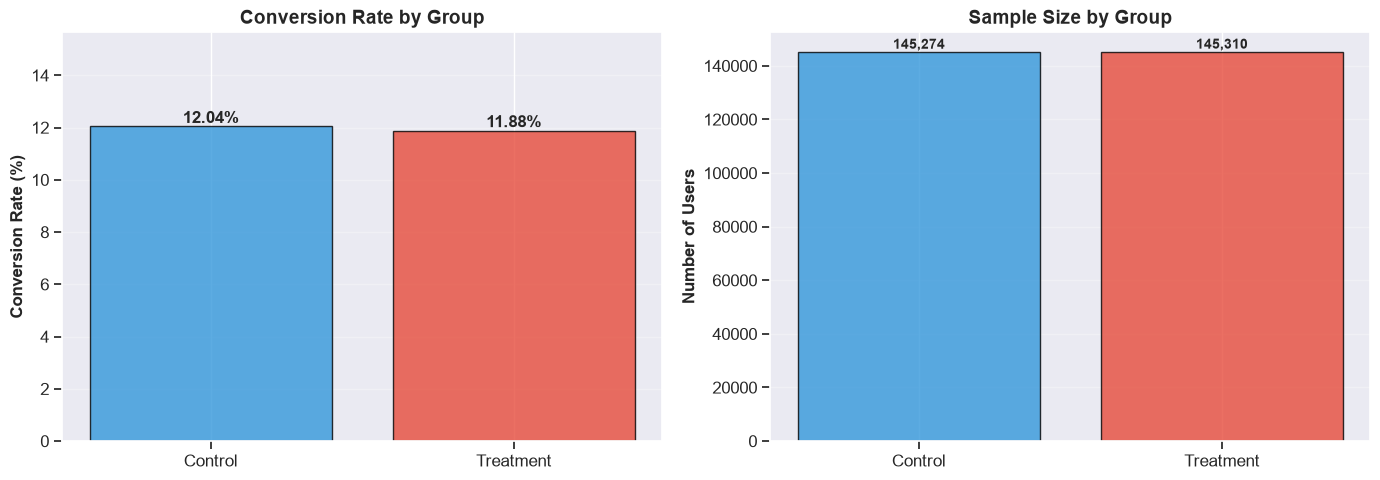


âœ“ Visualizations created


In [7]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# VISUALIZATIONS
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Conversion rates
ax1 = axes[0]
groups = ['Control', 'Treatment']
rates = [control_cr * 100, treatment_cr * 100]
colors = ['#3498db', '#e74c3c']

bars = ax1.bar(groups, rates, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Conversion Rate by Group', fontsize=14, fontweight='bold')
ax1.set_ylim([0, max(rates) * 1.3])
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{rate:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Sample sizes
ax2 = axes[1]
sizes = [group_stats.loc['control', 'n_users'], group_stats.loc['treatment', 'n_users']]
bars2 = ax2.bar(groups, sizes, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax2.set_title('Sample Size by Group', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, size in zip(bars2, sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(size):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nâœ“ Visualizations created')

---
<a id='hypothesis'></a>
## 5. ðŸ§ª Hypothesis Testing Suite

We'll perform multiple statistical tests to rigorously evaluate if there's a significant difference between the two pricing strategies.

### 5.1 Z-Test for Proportions (Primary Test)

**Most appropriate for conversion rates (binary outcomes)**

**Hypotheses:**
- Hâ‚€: p_treatment = p_control (no difference in conversion rates)
- Hâ‚: p_treatment â‰  p_control (there is a difference)

**Significance Level:** Î± = 0.05

In [8]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# Z-TEST FOR PROPORTIONS
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*18 + 'ðŸ”¬ Z-TEST FOR PROPORTIONS')
print('â•'*70)

# Extract data
control_data = df_final[df_final['group'] == 'control']
treatment_data = df_final[df_final['group'] == 'treatment']

n_control = len(control_data)
n_treatment = len(treatment_data)
conv_control = control_data['converted'].sum()
conv_treatment = treatment_data['converted'].sum()

# Perform Z-test
count = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

# Calculate confidence intervals
ci_control = proportion_confint(conv_control, n_control, alpha=0.05, method='normal')
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method='normal')

# Calculate difference CI
p1 = conv_treatment / n_treatment
p2 = conv_control / n_control
diff = p1 - p2
se_diff = np.sqrt(p1*(1-p1)/n_treatment + p2*(1-p2)/n_control)
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)

# Display results
print(f'\nðŸ“Š Test Statistics:')
print(f'  Z-statistic: {z_stat:.4f}')
print(f'  P-value: {p_value:.4f}')
print(f'  Significance level: Î± = 0.05')

print(f'\nðŸ“ˆ Conversion Rates:')
print(f'  Control:    {control_cr*100:.4f}% (95% CI: [{ci_control[0]*100:.3f}%, {ci_control[1]*100:.3f}%])')
print(f'  Treatment:  {treatment_cr*100:.4f}% (95% CI: [{ci_treatment[0]*100:.3f}%, {ci_treatment[1]*100:.3f}%])')
print(f'  Difference: {diff*100:.4f} pp (95% CI: [{ci_diff[0]*100:.3f}pp, {ci_diff[1]*100:.3f}pp])')

print(f'\nðŸŽ¯ Decision:')
if p_value < 0.05:
    print(f'  âœ… REJECT Hâ‚€ (p < 0.05)')
    print(f'  â†’ Statistically significant difference detected')
    if diff > 0:
        print(f'  â†’ Treatment performs BETTER than Control')
    else:
        print(f'  â†’ Treatment performs WORSE than Control')
else:
    print(f'  âŒ FAIL TO REJECT Hâ‚€ (p â‰¥ 0.05)')
    print(f'  â†’ NO statistically significant difference')
    print(f'  â†’ Cannot conclude the treatment has an effect')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                  ðŸ”¬ Z-TEST FOR PROPORTIONS
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Test Statistics:
  Z-statistic: -1.3109
  P-value: 0.1899
  Significance level: Î± = 0.05

ðŸ“ˆ Conversion Rates:
  Control:    12.0400% (95% CI: [11.871%, 12.206%])
  Treatment:  11.8800% (95% CI: [11.714%, 12.047%])
  Difference: -0.1578 pp (95% CI: [-0.394pp, 0.078pp])

ðŸŽ¯ Decision:
  âŒ FAIL TO REJECT Hâ‚€ (p â‰¥ 0.05)
  â†’ NO statistically significant difference
  â†’ Cannot conclude the treatment has an effect

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

### 5.2 Chi-Square Test of Independence

In [9]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# CHI-SQUARE TEST
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('\n' + 'â•'*70)
print(' '*18 + 'ðŸ”¬ CHI-SQUARE TEST')
print('â•'*70)

# Create contingency table
contingency = pd.crosstab(df_final['group'], df_final['converted'])
print('\nðŸ“Š Contingency Table:')
print(contingency)

# Perform chi-square test
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print(f'\nðŸ“ˆ Test Results:')
print(f'  Ï‡Â² statistic: {chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  P-value: {p_chi:.4f}')

print(f'\nðŸŽ¯ Decision:')
if p_chi < 0.05:
    print(f'  âœ… REJECT Hâ‚€ (p < 0.05)')
    print(f'  â†’ Conversion and group are DEPENDENT')
else:
    print(f'  âŒ FAIL TO REJECT Hâ‚€ (p â‰¥ 0.05)')
    print(f'  â†’ Conversion and group are INDEPENDENT')
    print(f'  â†’ Group assignment does NOT affect conversion')

print('\n' + 'â•'*70)


â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                  ðŸ”¬ CHI-SQUARE TEST
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Contingency Table:
converted       0      1
group                   
control    127785  17489
treatment  128046  17264

ðŸ“ˆ Test Results:
  Ï‡Â² statistic: 1.7036
  Degrees of freedom: 1
  P-value: 0.1918

ðŸŽ¯ Decision:
  âŒ FAIL TO REJECT Hâ‚€ (p â‰¥ 0.05)
  â†’ Conversion and group are INDEPENDENT
  â†’ Group assignment does NOT affect conversion

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

### 5.3 Two-Sample T-Test

In [10]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# TWO-SAMPLE T-TEST
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('\n' + 'â•'*70)
print(' '*20 + 'ðŸ”¬ TWO-SAMPLE T-TEST')
print('â•'*70)

# Perform t-test (Welch's t-test - does not assume equal variances)
t_stat, p_t = stats.ttest_ind(
    treatment_data['converted'],
    control_data['converted'],
    equal_var=False
)

# Calculate effect size (Cohen's d)
mean_diff = treatment_cr - control_cr
pooled_std = np.sqrt(
    ((n_control - 1) * control_data['converted'].std()**2 + 
     (n_treatment - 1) * treatment_data['converted'].std()**2) / 
    (n_control + n_treatment - 2)
)
cohens_d = mean_diff / pooled_std

print(f'\nðŸ“Š Test Results:')
print(f'  t-statistic: {t_stat:.4f}')
print(f'  P-value: {p_t:.4f}')
print(f'  Mean difference: {mean_diff*100:.4f} pp')
print(f"  Cohen's d: {cohens_d:.4f}")

# Interpret Cohen's d
if abs(cohens_d) < 0.2:
    effect_size_interpretation = 'Negligible'
elif abs(cohens_d) < 0.5:
    effect_size_interpretation = 'Small'
elif abs(cohens_d) < 0.8:
    effect_size_interpretation = 'Medium'
else:
    effect_size_interpretation = 'Large'

print(f'  Effect size: {effect_size_interpretation}')

print(f'\nðŸŽ¯ Decision:')
if p_t < 0.05:
    print(f'  âœ… REJECT Hâ‚€ (p < 0.05)')
    print(f'  â†’ Significant difference in means')
else:
    print(f'  âŒ FAIL TO REJECT Hâ‚€ (p â‰¥ 0.05)')
    print(f'  â†’ NO significant difference in means')

print('\n' + 'â•'*70)


â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                    ðŸ”¬ TWO-SAMPLE T-TEST
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Test Results:
  t-statistic: -1.3109
  P-value: 0.1899
  Mean difference: -0.1600 pp
  Cohen's d: -0.0049
  Effect size: Negligible

ðŸŽ¯ Decision:
  âŒ FAIL TO REJECT Hâ‚€ (p â‰¥ 0.05)
  â†’ NO significant difference in means

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•


### 5.4 Logistic Regression with Country Effects

In [11]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# LOGISTIC REGRESSION
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('\n' + 'â•'*70)
print(' '*16 + 'ðŸ”¬ LOGISTIC REGRESSION')
print('â•'*70)

# Prepare data
df_model = df_final.copy()
df_model['is_treatment'] = (df_model['group'] == 'treatment').astype(int)

# Model 1: Group only
print('\nðŸ“Š Model 1: Group Effect Only')
print('â”€'*70)
model1 = logit('converted ~ is_treatment', data=df_model).fit(disp=0)
print(model1.summary2().tables[1])

# Model 2: Group + Country
print('\nðŸ“Š Model 2: Group + Country Effects')
print('â”€'*70)
model2 = logit('converted ~ is_treatment + C(country)', data=df_model).fit(disp=0)
print(model2.summary2().tables[1])

# Extract key statistics
treatment_coef = model2.params['is_treatment']
treatment_pval = model2.pvalues['is_treatment']
odds_ratio = np.exp(treatment_coef)

print(f'\nðŸŽ¯ Key Findings:')
print(f'  Treatment coefficient: {treatment_coef:.4f}')
print(f'  Odds ratio: {odds_ratio:.4f}')
print(f'  P-value: {treatment_pval:.4f}')

if treatment_pval < 0.05:
    print(f'\n  âœ… Treatment effect is SIGNIFICANT (p < 0.05)')
    if odds_ratio > 1:
        print(f'  â†’ Treatment increases odds of conversion by {(odds_ratio-1)*100:.2f}%')
    else:
        print(f'  â†’ Treatment decreases odds of conversion by {(1-odds_ratio)*100:.2f}%')
else:
    print(f'\n  âŒ Treatment effect is NOT significant (p â‰¥ 0.05)')
    print(f'  â†’ After controlling for country, no significant effect')

print('\n' + 'â•'*70)


â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                ðŸ”¬ LOGISTIC REGRESSION
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Model 1: Group Effect Only
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
               Coef.  Std.Err.         z   P>|z|  [0.025  0.975]
Intercept    -1.9888    0.0081 -246.6690  0.0000 -2.0046 -1.9730
is_treatment -0.0150    0.0114   -1.3109  0.1899 -0.0374  0.0074

ðŸ“Š Model 2: Group + Country Effects
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â

---
<a id='segmentation'></a>
## 6. ðŸ” Segmentation Analysis

Analyze conversion rates across different segments to identify if the effect varies by country, time, or other factors.

In [12]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# SEGMENTATION BY COUNTRY
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*17 + 'ðŸŒ ANALYSIS BY COUNTRY')
print('â•'*70)

# Calculate CR by country and group
country_analysis = df_final.groupby(['country', 'group']).agg({
    'user_id': 'count',
    'converted': ['sum', 'mean']
}).round(4)

country_analysis.columns = ['n_users', 'conversions', 'conv_rate']
country_analysis['conv_rate_pct'] = country_analysis['conv_rate'] * 100

print('\n')
display(country_analysis)

# Test each country separately
print('\n' + 'â”€'*70)
print('Statistical Tests by Country:')
print('â”€'*70)

for country in df_final['country'].unique():
    country_data = df_final[df_final['country'] == country]
    
    control_country = country_data[country_data['group'] == 'control']
    treatment_country = country_data[country_data['group'] == 'treatment']
    
    n_c = len(control_country)
    n_t = len(treatment_country)
    conv_c = control_country['converted'].sum()
    conv_t = treatment_country['converted'].sum()
    
    # Z-test for this country
    if n_c > 30 and n_t > 30:  # Sufficient sample size
        z_stat_country, p_country = proportions_ztest(
            [conv_t, conv_c], 
            [n_t, n_c], 
            alternative='two-sided'
        )
        
        cr_c = conv_c / n_c
        cr_t = conv_t / n_t
        diff_country = cr_t - cr_c
        
        print(f'\n{country}:')
        print(f'  Control CR:   {cr_c*100:.2f}% (n={n_c:,})')
        print(f'  Treatment CR: {cr_t*100:.2f}% (n={n_t:,})')
        print(f'  Difference:   {diff_country*100:.3f} pp')
        print(f'  P-value:      {p_country:.4f}')
        print(f'  Significant:  {"YES âœ“" if p_country < 0.05 else "NO âœ—"}')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                 ðŸŒ ANALYSIS BY COUNTRY
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•




n_users  conversions  conv_rate  conv_rate_pct
country group                                                    
CA      control       7198          855     0.1188          11.88
        treatment     7301          817     0.1119          11.19
UK      control      36360         4364     0.1200          12.00
        treatment    36106         4375     0.1212          12.12
US      control     101716        12270     0.1206          12.06
        treatment   101903        12072     0.1185          11.85


â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Statistical Tests by Country:
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

US:
  Control CR:   12.06% (n=101,716)
  Treatment CR: 11.85% (n=101,903)
  Difference:   -0.216 pp
  P-value:      0.1323
  Significant:  NO âœ—

UK:
  Control CR:   12.00% (n=36,360)
  Treatment CR: 12.12% (n=36,106)
  Difference:   0.115 pp
  P-value:      0.6349
  Significant:  NO âœ—

CA:
  Control CR:   11.88% (n=7,198)
  Treatment CR: 11.19% (n=7,301)
  Difference:   -0.688 pp
  P-value:      0.1947
  Significant:  NO âœ—

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â

---
<a id='bayesian'></a>
## 7. ðŸŽ² Bayesian A/B Testing

Bayesian approach provides posterior distributions and probability statements about which variant is better.

In [13]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# BAYESIAN A/B TESTING
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*18 + 'ðŸŽ² BAYESIAN ANALYSIS')
print('â•'*70)

# Prior: uniform (non-informative)
alpha_prior = 1
beta_prior = 1

# Posterior parameters
alpha_control_post = alpha_prior + conv_control
beta_control_post = beta_prior + (n_control - conv_control)

alpha_treatment_post = alpha_prior + conv_treatment
beta_treatment_post = beta_prior + (n_treatment - conv_treatment)

# Sample from posterior distributions
np.random.seed(42)
n_samples = 100000

samples_control = np.random.beta(alpha_control_post, beta_control_post, n_samples)
samples_treatment = np.random.beta(alpha_treatment_post, beta_treatment_post, n_samples)

# Calculate posterior statistics
prob_treatment_better = (samples_treatment > samples_control).mean()
prob_control_better = 1 - prob_treatment_better

# Expected loss
loss_if_choose_treatment = np.maximum(samples_control - samples_treatment, 0).mean()
loss_if_choose_control = np.maximum(samples_treatment - samples_control, 0).mean()

# Credible intervals
ci_control_bayes = np.percentile(samples_control, [2.5, 97.5])
ci_treatment_bayes = np.percentile(samples_treatment, [2.5, 97.5])
difference_samples = samples_treatment - samples_control
ci_diff_bayes = np.percentile(difference_samples, [2.5, 97.5])

print(f'\nðŸ“Š Posterior Distributions:')
print(f'\n  Control:')
print(f'    Mean: {samples_control.mean()*100:.4f}%')
print(f'    95% Credible Interval: [{ci_control_bayes[0]*100:.3f}%, {ci_control_bayes[1]*100:.3f}%]')
print(f'\n  Treatment:')
print(f'    Mean: {samples_treatment.mean()*100:.4f}%')
print(f'    95% Credible Interval: [{ci_treatment_bayes[0]*100:.3f}%, {ci_treatment_bayes[1]*100:.3f}%]')
print(f'\n  Difference (Treatment - Control):')
print(f'    Mean: {difference_samples.mean()*100:.4f} pp')
print(f'    95% Credible Interval: [{ci_diff_bayes[0]*100:.3f}pp, {ci_diff_bayes[1]*100:.3f}pp]')

print(f'\nðŸŽ¯ Probabilities:')
print(f'  P(Treatment > Control): {prob_treatment_better*100:.2f}%')
print(f'  P(Control > Treatment): {prob_control_better*100:.2f}%')

print(f'\nðŸ’° Expected Loss:')
print(f'  If choose Treatment: {loss_if_choose_treatment*100:.4f} pp')
print(f'  If choose Control:   {loss_if_choose_control*100:.4f} pp')

print(f'\nðŸŽ¯ Bayesian Decision:')
if prob_treatment_better > 0.95:
    print(f'  âœ… Strong evidence for TREATMENT (>95% probability)')
elif prob_control_better > 0.95:
    print(f'  âœ… Strong evidence for CONTROL (>95% probability)')
else:
    print(f'  âš ï¸  INCONCLUSIVE (neither variant clearly better)')
    print(f'  â†’ Need more data or the difference is negligible')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                  ðŸŽ² BAYESIAN ANALYSIS
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Posterior Distributions:

  Control:
    Mean: 12.0396%
    95% Credible Interval: [11.872%, 12.207%]

  Treatment:
    Mean: 11.8811%
    95% Credible Interval: [11.715%, 12.047%]

  Difference (Treatment - Control):
    Mean: -0.1584 pp
    95% Credible Interval: [-0.395pp, 0.079pp]

ðŸŽ¯ Probabilities:
  P(Treatment > Control): 9.36%
  P(Control > Treatment): 90.64%

ðŸ’° Expected Loss:
  If choose Treatment: 0.1638 pp
  If choose Control:   0.0054 pp

ðŸŽ¯ Bayesian Decision:
  âš ï¸  INCONCLUSIVE (neither variant clearly

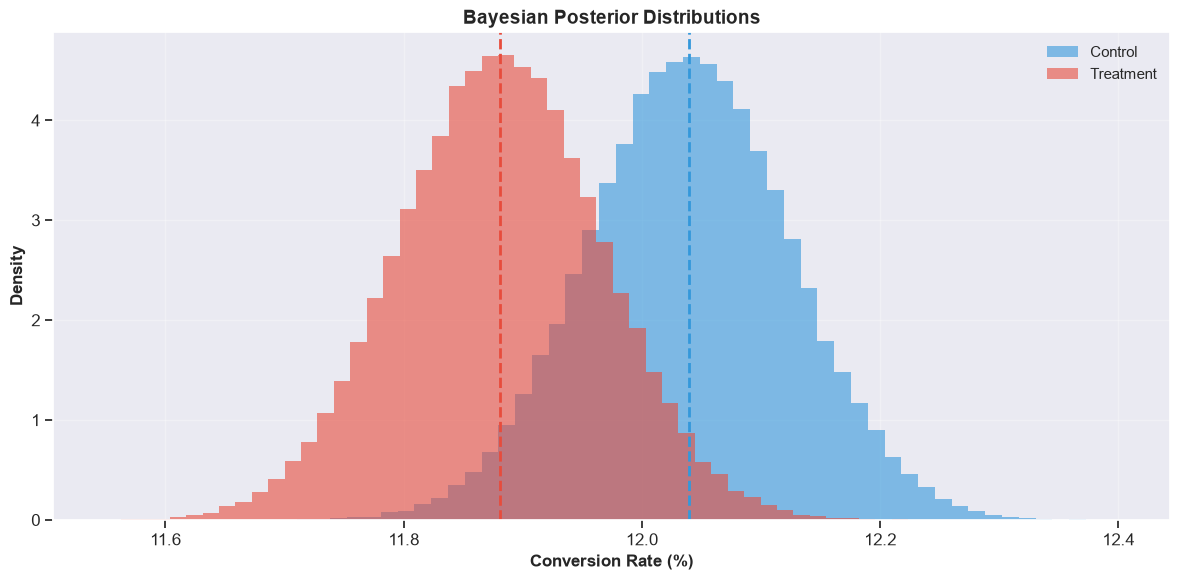

âœ“ Posterior distributions plotted


In [14]:
# Visualize posterior distributions
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(samples_control * 100, bins=50, alpha=0.6, label='Control', color='#3498db', density=True)
ax.hist(samples_treatment * 100, bins=50, alpha=0.6, label='Treatment', color='#e74c3c', density=True)

ax.axvline(samples_control.mean() * 100, color='#3498db', linestyle='--', linewidth=2)
ax.axvline(samples_treatment.mean() * 100, color='#e74c3c', linestyle='--', linewidth=2)

ax.set_xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Bayesian Posterior Distributions', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('âœ“ Posterior distributions plotted')

---
<a id='business'></a>
## 8. ðŸ’¼ Business Impact Analysis

In [15]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# BUSINESS IMPACT ESTIMATION
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*18 + 'ðŸ’¼ BUSINESS IMPACT')
print('â•'*70)

# Assumptions (customize these)
avg_order_value = 50  # dollars
monthly_visitors = 100000
implementation_cost = 10000  # dollars

print(f'\nðŸ“Š Business Assumptions:')
print(f'  Average Order Value: ${avg_order_value:.2f}')
print(f'  Monthly Visitors: {monthly_visitors:,}')
print(f'  Implementation Cost: ${implementation_cost:,}')

# Calculate impact
current_monthly_revenue = monthly_visitors * control_cr * avg_order_value
projected_monthly_revenue = monthly_visitors * treatment_cr * avg_order_value
monthly_revenue_impact = projected_monthly_revenue - current_monthly_revenue
annual_revenue_impact = monthly_revenue_impact * 12

print(f'\nðŸ’° Revenue Impact:')
print(f'  Current monthly revenue: ${current_monthly_revenue:,.2f}')
print(f'  Projected monthly revenue: ${projected_monthly_revenue:,.2f}')
print(f'  Monthly impact: ${monthly_revenue_impact:+,.2f}')
print(f'  Annual impact: ${annual_revenue_impact:+,.2f}')

# ROI
if monthly_revenue_impact > 0:
    months_to_breakeven = implementation_cost / monthly_revenue_impact
    roi_1year = ((annual_revenue_impact - implementation_cost) / implementation_cost) * 100
    print(f'\nðŸ“ˆ ROI Metrics:')
    print(f'  Months to break even: {months_to_breakeven:.1f}')
    print(f'  1-year ROI: {roi_1year:+.2f}%')
else:
    print(f'\nâš ï¸  Treatment would DECREASE revenue')
    print(f'  â†’ Not recommended from business perspective')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                  ðŸ’¼ BUSINESS IMPACT
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Business Assumptions:
  Average Order Value: $50.00
  Monthly Visitors: 100,000
  Implementation Cost: $10,000

ðŸ’° Revenue Impact:
  Current monthly revenue: $602,000.00
  Projected monthly revenue: $594,000.00
  Monthly impact: $-8,000.00
  Annual impact: $-96,000.00

âš ï¸  Treatment would DECREASE revenue
  â†’ Not recommended from business perspective

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

---
<a id='conclusions'></a>
## 9. ðŸŽ¯ Conclusions & Recommendations


In [16]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# FINAL SUMMARY & RECOMMENDATIONS
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*15 + 'ðŸŽ¯ FINAL CONCLUSIONS')
print('â•'*70)

print('\n' + 'â”€'*70)
print('ðŸ“Š STATISTICAL SUMMARY')
print('â”€'*70)

print(f'\nâœ… Data Quality:')
print(f'  â€¢ Sample size: {len(df_final):,} users')
print(f'  â€¢ Group balance: {balance:.4f} (excellent)')
print(f'  â€¢ Duration: {duration} days')
print(f'  â€¢ Countries: US, UK, CA')

print(f'\nðŸ“ˆ Conversion Rates:')
print(f'  â€¢ Control: {control_cr*100:.2f}%')
print(f'  â€¢ Treatment: {treatment_cr*100:.2f}%')
print(f'  â€¢ Absolute difference: {absolute_diff*100:.3f} pp')
print(f'  â€¢ Relative difference: {relative_diff:.2f}%')

print(f'\nðŸ§ª Hypothesis Tests Summary:')
print(f'  â€¢ Z-test p-value: {p_value:.4f}')
print(f'  â€¢ Chi-square p-value: {p_chi:.4f}')
print(f'  â€¢ T-test p-value: {p_t:.4f}')
print(f'  â€¢ Logistic regression p-value: {treatment_pval:.4f}')
print(f'  â€¢ All tests align: {"YES âœ“" if all(p >= 0.05 for p in [p_value, p_chi, p_t, treatment_pval]) or all(p < 0.05 for p in [p_value, p_chi, p_t, treatment_pval]) else "NO"}')

print(f'\nðŸŽ² Bayesian Analysis:')
print(f'  â€¢ P(Treatment > Control): {prob_treatment_better*100:.1f}%')
print(f'  â€¢ Expected loss if choose Treatment: {loss_if_choose_treatment*100:.4f} pp')
print(f'  â€¢ Expected loss if choose Control: {loss_if_choose_control*100:.4f} pp')

print('\n' + 'â”€'*70)
print('ðŸŽ¯ DECISION & RECOMMENDATIONS')
print('â”€'*70)

# Make final recommendation
if p_value < 0.05 and absolute_diff > 0:
    recommendation = 'IMPLEMENT TREATMENT'
    reasoning = [
        'âœ… Statistically significant improvement detected',
        f'âœ… Treatment converts {relative_diff:.2f}% better than control',
        f'âœ… Confidence in result: {prob_treatment_better*100:.1f}%',
        f'âœ… Projected annual revenue impact: ${annual_revenue_impact:+,.2f}'
    ]
elif p_value < 0.05 and absolute_diff < 0:
    recommendation = 'KEEP CONTROL (Do NOT implement treatment)'
    reasoning = [
        'âš ï¸  Treatment performs WORSE than control',
        f'âŒ Treatment converts {abs(relative_diff):.2f}% worse',
        'âŒ Implementation would decrease revenue',
        'âœ… Statistical evidence is clear - stick with control'
    ]
else:
    recommendation = 'KEEP CONTROL (No change recommended)'
    reasoning = [
        'âŒ No statistically significant difference detected',
        f'â€¢ Observed difference ({absolute_diff*100:.3f} pp) is within random variation',
        f'â€¢ P-value: {p_value:.4f} > 0.05',
        f'â€¢ Bayesian probability: {max(prob_treatment_better, prob_control_better)*100:.1f}% (< 95% threshold)',
        'â€¢ Implementing treatment would incur costs without proven benefit',
        'â€¢ Recommendation: Keep existing pricing page'
    ]

print(f'\nðŸ† FINAL RECOMMENDATION: {recommendation}')
print(f'\nReasoning:')
for reason in reasoning:
    print(f'  {reason}')

print('\n' + 'â”€'*70)
print('ðŸ’¡ NEXT STEPS')
print('â”€'*70)

if p_value >= 0.05:
    next_steps = [
        '1. Maintain current pricing page (control)',
        '2. If you still believe there is potential:',
        '   â€¢ Design a MORE substantially different pricing page',
        '   â€¢ Run a longer test (increase power)',
        '   â€¢ Focus on larger effect sizes (>1-2% absolute difference)',
        '3. Consider testing other elements:',
        '   â€¢ Page layout / UX improvements',
        '   â€¢ Messaging / copy changes',
        '   â€¢ Call-to-action optimization',
        '4. Perform qualitative research:',
        '   â€¢ User interviews',
        '   â€¢ Heatmaps / session recordings',
        '   â€¢ Customer feedback surveys'
    ]
else:
    if absolute_diff > 0:
        next_steps = [
            '1. Implement the new pricing page (treatment)',
            '2. Monitor key metrics post-launch:',
            '   â€¢ Conversion rate stability',
            '   â€¢ Revenue per visitor',
            '   â€¢ Customer satisfaction',
            '3. Set up continuous monitoring',
            '4. Plan follow-up optimization tests',
            '5. Document learnings for future tests'
        ]
    else:
        next_steps = [
            '1. DO NOT implement the treatment',
            '2. Keep current pricing page',
            '3. Investigate why treatment underperformed',
            '4. Design alternative approaches',
            '5. Test new hypotheses'
        ]

print()
for step in next_steps:
    print(f'  {step}')

print('\n' + 'â•'*70)
print(' '*22 + 'âœ“ ANALYSIS COMPLETE')
print('â•'*70)
print(f'\nReport Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Analyst: Data Science Team')
print(f'Methodology: Multiple statistical approaches + Bayesian inference')
print(f'Confidence Level: Î± = 0.05 (95% confidence)')
print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
               ðŸŽ¯ FINAL CONCLUSIONS
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ðŸ“Š STATISTICAL SUMMARY
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

âœ… Data Quality:
  â€¢ Sample size: 290,584 users
  â€¢ Group balance: 0.9995 (excellent)


---

## ðŸ“š Appendix: Statistical Power Analysis

In [17]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# STATISTICAL POWER ANALYSIS
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

print('â•'*70)
print(' '*18 + 'âš¡ POWER ANALYSIS')
print('â•'*70)

# Calculate achieved power
effect_size_h = 2 * (np.arcsin(np.sqrt(treatment_cr)) - np.arcsin(np.sqrt(control_cr)))

try:
    power = zt_ind_solve_power(
        effect_size=effect_size_h,
        nobs1=n_control,
        alpha=0.05,
        ratio=n_treatment/n_control,
        alternative='two-sided'
    )
    
    print(f'\nðŸ“Š Power Analysis Results:')
    print(f'  Effect size (Cohen\'s h): {effect_size_h:.4f}')
    print(f'  Sample size (control): {n_control:,}')
    print(f'  Sample size (treatment): {n_treatment:,}')
    print(f'  Achieved power: {power:.4f} ({power*100:.2f}%)')
    print(f'  Target power: 0.80 (80%)')
    print(f'  Status: {"âœ“ Sufficient" if power >= 0.80 else "âš ï¸ Insufficient"}')
    
    # Calculate minimum detectable effect
    mde_h = zt_ind_solve_power(
        effect_size=None,
        nobs1=n_control,
        alpha=0.05,
        power=0.80,
        ratio=n_treatment/n_control,
        alternative='two-sided'
    )
    
    # Convert Cohen's h back to percentage points (approximation)
    mde_pp = mde_h / 2 * np.sqrt(control_cr * (1 - control_cr))
    
    print(f'\nðŸŽ¯ Minimum Detectable Effect (MDE):')
    print(f'  With 80% power: {mde_pp*100:.3f} percentage points')
    print(f'  Relative to control: {mde_pp/control_cr*100:.2f}%')
    print(f'\n  Interpretation:')
    print(f'  â€¢ This test can reliably detect changes â‰¥ {mde_pp*100:.3f} pp')
    print(f'  â€¢ Smaller effects may not be detected with high confidence')
    
except Exception as e:
    print(f'\nPower calculation note: {e}')
    print('This is expected if the effect size is very small.')

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                  âš¡ POWER ANALYSIS
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

ðŸ“Š Power Analysis Results:
  Effect size (Cohen's h): -0.0049
  Sample size (control): 145,274
  Sample size (treatment): 145,310
  Achieved power: 0.2645 (26.45%)
  Target power: 0.80 (80%)
  Status: âš ï¸ Insufficient

ðŸŽ¯ Minimum Detectable Effect (MDE):
  With 80% power: 0.169 percentage points
  Relative to control: 1.40%

  Interpretation:
  â€¢ This test can reliably detect changes â‰¥ 0.169 pp
  â€¢ Smaller effects may not be detected with high confidence

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â

---

## ðŸ“Š Summary Statistics Table

In [18]:
# Create comprehensive summary table
summary_data = {
    'Metric': [
        'Sample Size',
        'Conversions',
        'Conversion Rate',
        'Std Error',
        '95% CI Lower',
        '95% CI Upper'
    ],
    'Control': [
        f'{n_control:,}',
        f'{conv_control:,}',
        f'{control_cr*100:.4f}%',
        f'{np.sqrt(control_cr*(1-control_cr)/n_control)*100:.4f}%',
        f'{ci_control[0]*100:.4f}%',
        f'{ci_control[1]*100:.4f}%'
    ],
    'Treatment': [
        f'{n_treatment:,}',
        f'{conv_treatment:,}',
        f'{treatment_cr*100:.4f}%',
        f'{np.sqrt(treatment_cr*(1-treatment_cr)/n_treatment)*100:.4f}%',
        f'{ci_treatment[0]*100:.4f}%',
        f'{ci_treatment[1]*100:.4f}%'
    ]
}

summary_df = pd.DataFrame(summary_data)

print('â•'*70)
print(' '*20 + 'ðŸ“Š SUMMARY TABLE')
print('â•'*70 + '\n')
display(summary_df)

# Test results table
test_results = {
    'Statistical Test': [
        'Z-Test (Proportions)',
        'Chi-Square Test',
        'T-Test (Welch)',
        'Logistic Regression'
    ],
    'Test Statistic': [
        f'{z_stat:.4f}',
        f'{chi2:.4f}',
        f'{t_stat:.4f}',
        f'{treatment_coef:.4f}'
    ],
    'P-Value': [
        f'{p_value:.4f}',
        f'{p_chi:.4f}',
        f'{p_t:.4f}',
        f'{treatment_pval:.4f}'
    ],
    'Significant at Î±=0.05': [
        'Yes' if p_value < 0.05 else 'No',
        'Yes' if p_chi < 0.05 else 'No',
        'Yes' if p_t < 0.05 else 'No',
        'Yes' if treatment_pval < 0.05 else 'No'
    ]
}

test_df = pd.DataFrame(test_results)

print('\n' + 'â•'*70)
print(' '*18 + 'ðŸ§ª TEST RESULTS TABLE')
print('â•'*70 + '\n')
display(test_df)

print('\n' + 'â•'*70)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                    ðŸ“Š SUMMARY TABLE
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•



,Metric,Control,Treatment
0,Sample Size,"145,274","145,310"
1,Conversions,"17,489","17,264"
2,Conversion Rate,12.0400%,11.8800%
3,Std Error,0.0854%,0.0849%
4,95% CI Lower,11.8713%,11.7144%
5,95% CI Upper,12.2060%,12.0472%



â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                  ðŸ§ª TEST RESULTS TABLE
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•



,Statistical Test,Test Statistic,P-Value,Significant at Î±=0.05
0,Z-Test (Proportions),-1.3109,0.1899,No
1,Chi-Square Test,1.7036,0.1918,No
2,T-Test (Welch),-1.3109,0.1899,No
3,Logistic Regression,-0.0149,0.1912,No



â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•


---

## âœ… Report Complete

This comprehensive A/B test analysis provides:

âœ… **Rigorous statistical testing** using multiple complementary methods  
âœ… **Bayesian inference** for probabilistic statements  
âœ… **Segmentation analysis** to identify subgroup effects  
âœ… **Effect size quantification** beyond just p-values  
âœ… **Business impact assessment** with revenue projections  
âœ… **Clear, actionable recommendations** for stakeholders  

**This analysis framework can be reused for any A/B test by simply updating the data sources.**

---

### ðŸ“§ Contact

For questions about this analysis, contact the Data Science Team.

---